In [ ]:
# ============================================
# CALIFORNIA HOUSING PRICE PREDICTION
# ============================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.inspection import permutation_importance

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving housing.csv to housing.csv


In [ ]:
df = pd.read_csv("housing.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape: (20640, 10)

Column Names:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
longitude,20640.0,NaN,NaN,NaN,-119.569704,2.003532,-124.35,-121.8,-118.49,-118.01,-114.31
latitude,20640.0,NaN,NaN,NaN,35.631861,2.135952,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,NaN,NaN,NaN,28.639486,12.585558,1.0,18.0,29.0,37.0,52.0
total_rooms,20640.0,NaN,NaN,NaN,2635.763081,2181.615252,2.0,1447.75,2127.0,3148.0,39320.0
total_bedrooms,20433.0,NaN,NaN,NaN,537.870553,421.38507,1.0,296.0,435.0,647.0,6445.0
population,20640.0,NaN,NaN,NaN,1425.476744,1132.462122,3.0,787.0,1166.0,1725.0,35682.0
households,20640.0,NaN,NaN,NaN,499.53968,382.329753,1.0,280.0,409.0,605.0,6082.0
median_income,20640.0,NaN,NaN,NaN,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,NaN,NaN,NaN,206855.816909,115395.615874,14999.0,119600.0,179700.0,264725.0,500001.0
ocean_proximity,20640,5,<1H OCEAN,9136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df) * 100).round(2)
})

missing_df[missing_df["Missing Values"] > 0]

,Missing Values,Percentage
total_bedrooms,207,1.0


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (20640, 10)


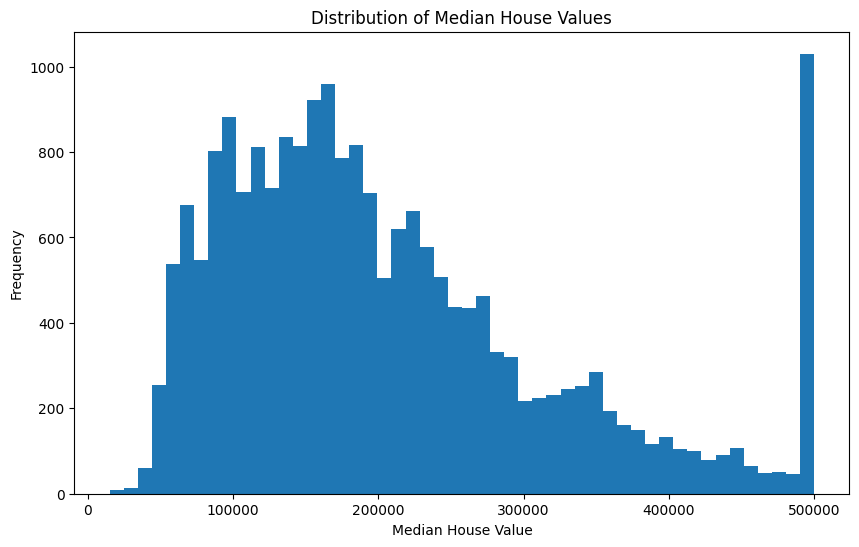

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(df["median_house_value"], bins=50)

plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of Median House Values")

plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()["median_house_value"].sort_values(ascending=False)

print(correlation)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


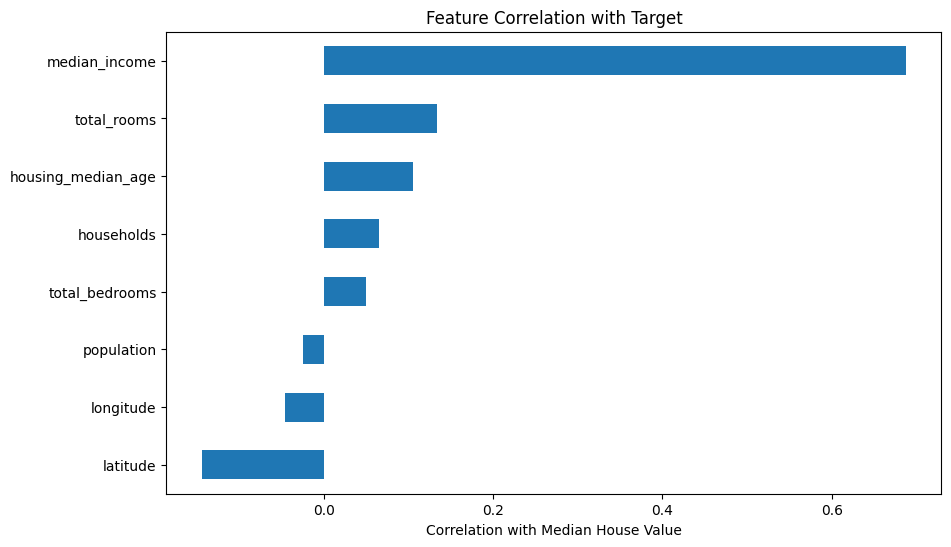

In [ ]:
plt.figure(figsize=(10, 6))

correlation.drop("median_house_value").sort_values().plot(kind="barh")

plt.xlabel("Correlation with Median House Value")
plt.title("Feature Correlation with Target")

plt.show()

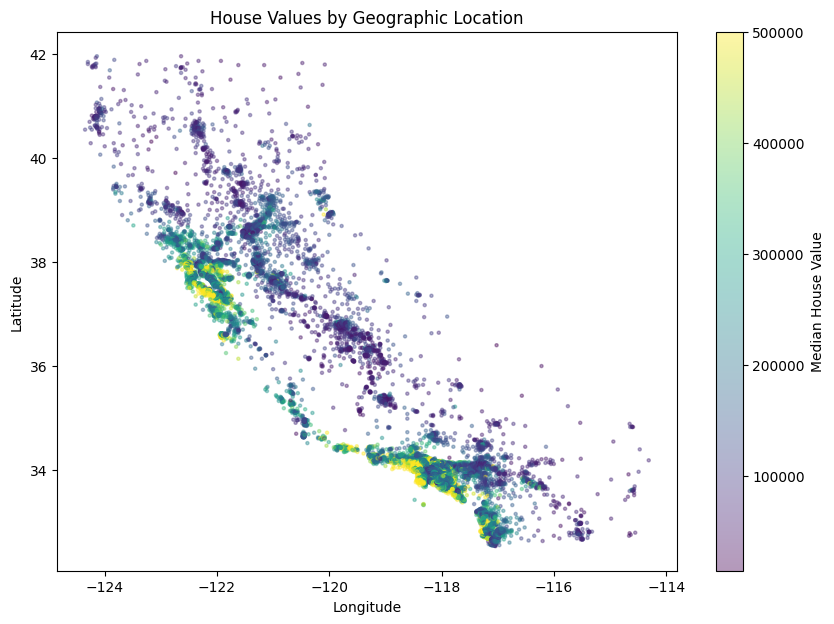

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_house_value"],
    s=5,
    alpha=0.4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Values by Geographic Location")

plt.colorbar(label="Median House Value")

plt.show()

In [ ]:
# Feature Engineering

df["rooms_per_household"] = df["total_rooms"] / df["households"]

df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

df["population_per_household"] = df["population"] / df["households"]

In [ ]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 12)
Target shape: (20640,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16512
Testing samples: 4128


In [ ]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

Categorical Features:
['ocean_proximity']


In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [ ]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("---------------------------")
print(f"MAE  : {linear_mae:,.2f}")
print(f"RMSE : {linear_rmse:,.2f}")
print(f"R²   : {linear_r2:.4f}")

Linear Regression
---------------------------
MAE  : 49,645.49
RMSE : 69,127.04
R²   : 0.6353


In [ ]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor")
print("---------------------------")
print(f"MAE  : {rf_mae:,.2f}")
print(f"RMSE : {rf_rmse:,.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Regressor
---------------------------
MAE  : 31,586.19
RMSE : 48,875.77
R²   : 0.8177


In [ ]:
extra_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

extra_model.fit(X_train, y_train)

extra_pred = extra_model.predict(X_test)

extra_mae = mean_absolute_error(y_test, extra_pred)
extra_rmse = np.sqrt(mean_squared_error(y_test, extra_pred))
extra_r2 = r2_score(y_test, extra_pred)

print("Extra Trees Regressor")
print("---------------------------")
print(f"MAE  : {extra_mae:,.2f}")
print(f"RMSE : {extra_rmse:,.2f}")
print(f"R²   : {extra_r2:.4f}")

Extra Trees Regressor
---------------------------
MAE  : 32,689.50
RMSE : 49,921.76
R²   : 0.8098


In [ ]:
gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=2,
        loss="huber",
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Regressor")
print("---------------------------")
print(f"MAE  : {gb_mae:,.2f}")
print(f"RMSE : {gb_rmse:,.2f}")
print(f"R²   : {gb_r2:.4f}")

Gradient Boosting Regressor
---------------------------
MAE  : 31,157.86
RMSE : 48,322.68
R²   : 0.8218


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        extra_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        extra_rmse,
        gb_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2,
        extra_r2,
        gb_r2
    ]
})

results = results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

results

,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,31157.861382,48322.679134,0.821805
1,Random Forest,31586.187642,48875.766696,0.817703
2,Extra Trees,32689.497042,49921.756406,0.809816
3,Linear Regression,49645.492445,69127.038299,0.635339


In [ ]:
best_model_name = results.iloc[0]["Model"]

print("Best Model:", best_model_name)
print(f"Best R² Score: {results.iloc[0]['R2 Score']:.4f}")
print(f"Best RMSE: {results.iloc[0]['RMSE']:,.2f}")
print(f"Best MAE: {results.iloc[0]['MAE']:,.2f}")

Best Model: Gradient Boosting
Best R² Score: 0.8218
Best RMSE: 48,322.68
Best MAE: 31,157.86


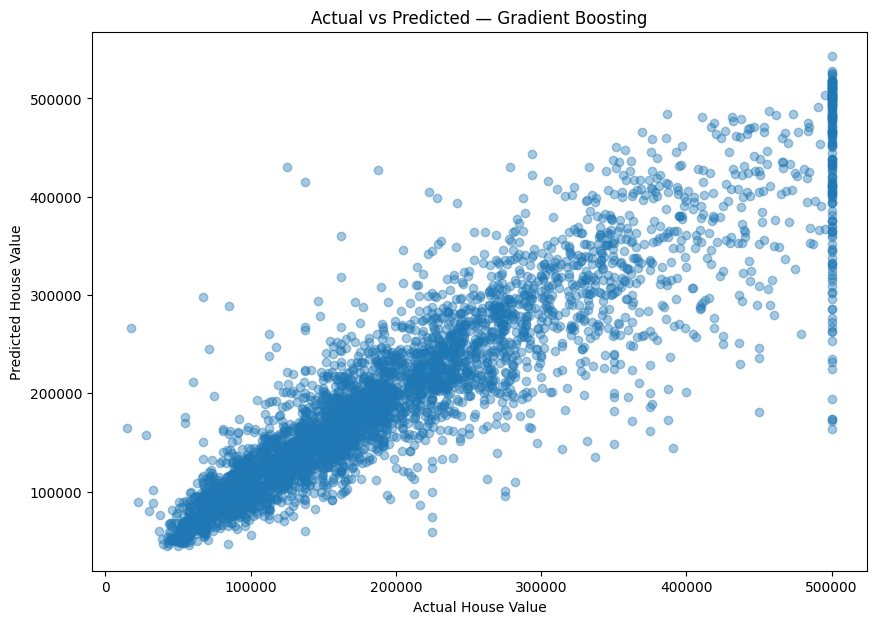

In [ ]:
predictions = {
    "Linear Regression": linear_pred,
    "Random Forest": rf_pred,
    "Extra Trees": extra_pred,
    "Gradient Boosting": gb_pred
}

best_predictions = predictions[best_model_name]

plt.figure(figsize=(10, 7))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.4
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title(f"Actual vs Predicted — {best_model_name}")

plt.show()

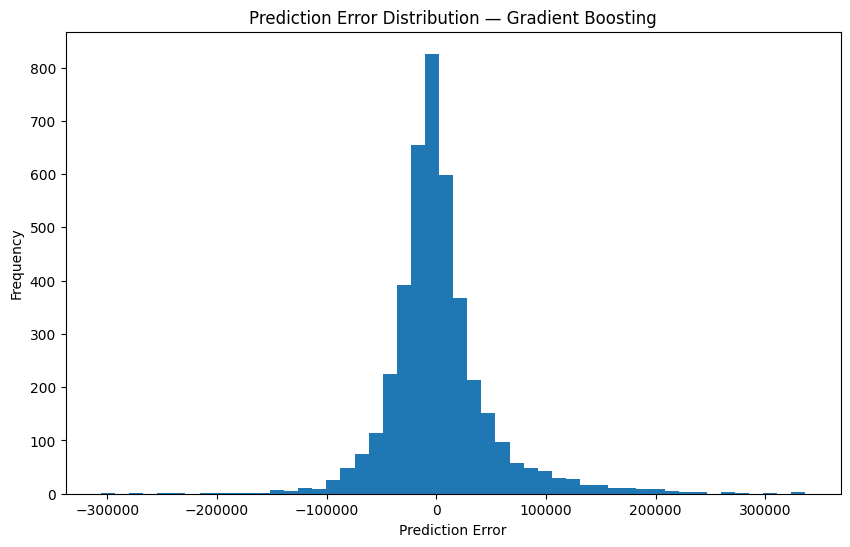

In [ ]:
errors = y_test - best_predictions

plt.figure(figsize=(10, 6))

plt.hist(errors, bins=50)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title(f"Prediction Error Distribution — {best_model_name}")

plt.show()

In [ ]:
best_tree_model = {
    "Random Forest": rf_model,
    "Extra Trees": extra_model,
    "Gradient Boosting": gb_model
}

if best_model_name in best_tree_model:

    model_pipeline = best_tree_model[best_model_name]

    feature_names = model_pipeline.named_steps[
        "preprocessor"
    ].get_feature_names_out()

    importances = model_pipeline.named_steps[
        "model"
    ].feature_importances_

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(
        "Importance",
        ascending=False
    )

    feature_importance.head(15)

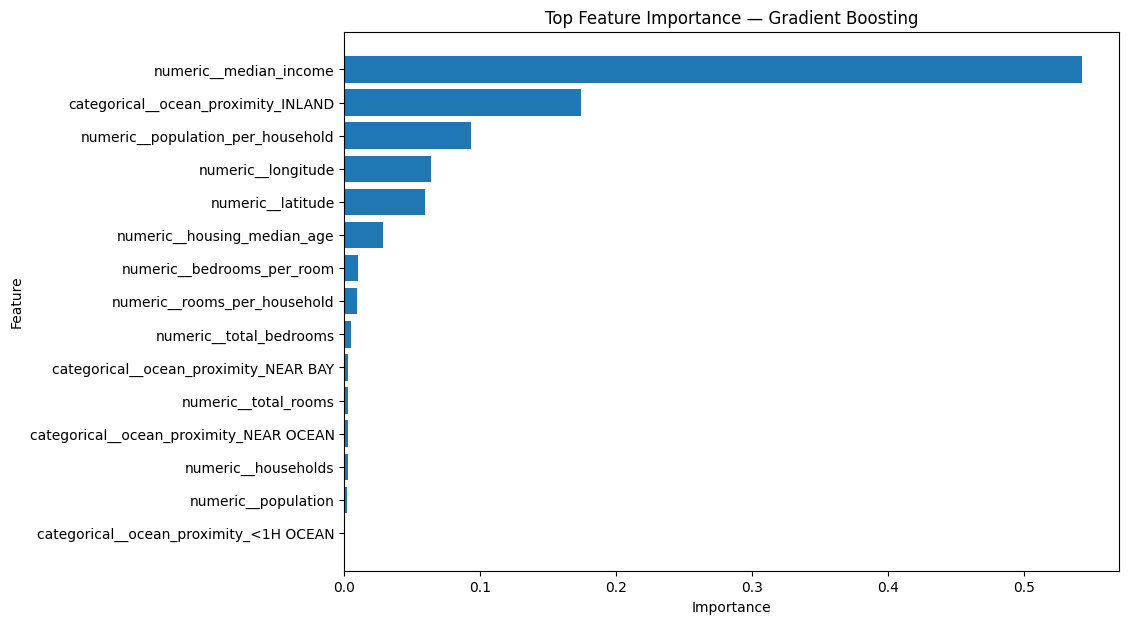

In [ ]:
if best_model_name in best_tree_model:

    top_features = feature_importance.head(15).sort_values(
        "Importance"
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Top Feature Importance — {best_model_name}")

    plt.show()

In [ ]:
sample = X_test.iloc[[0]]

actual_price = y_test.iloc[0]
predicted_price = best_predictions[0]

print("Sample House Prediction")
print("---------------------------")
print(f"Actual Price    : ${actual_price:,.2f}")
print(f"Predicted Price : ${predicted_price:,.2f}")
print(f"Difference      : ${abs(actual_price - predicted_price):,.2f}")

Sample House Prediction
---------------------------
Actual Price    : $47,700.00
Predicted Price : $52,308.39
Difference      : $4,608.39


In [ ]:
final_mae = mean_absolute_error(y_test, best_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, best_predictions))
final_r2 = r2_score(y_test, best_predictions)

print("=" * 50)
print("FINAL MODEL EVALUATION")
print("=" * 50)

print(f"Model : {best_model_name}")
print(f"MAE   : {final_mae:,.2f}")
print(f"RMSE  : {final_rmse:,.2f}")
print(f"R²    : {final_r2:.4f}")
print(f"R² %  : {final_r2 * 100:.2f}%")

FINAL MODEL EVALUATION
Model : Gradient Boosting
MAE   : 31,157.86
RMSE  : 48,322.68
R²    : 0.8218
R² %  : 82.18%


In [ ]:
# Check if Gradient Boosting model is available

print("Checking trained models...")

print("X_train exists:", "X_train" in globals())
print("X_test exists :", "X_test" in globals())

if "models" in globals():
    print("Available models:", list(models.keys()))
else:
    print("The 'models' dictionary is not available.")

Checking trained models...
X_train exists: True
X_test exists : True
The 'models' dictionary is not available.


In [ ]:
# Rebuild the Gradient Boosting model

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=2,
        loss="huber",
        random_state=42
    ))
])

# Train the model
best_model.fit(X_train, y_train)

# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Training metrics
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Testing metrics
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("GRADIENT BOOSTING - OVERFITTING CHECK")
print("-" * 50)
print(f"Training R²  : {train_r2:.4f}")
print(f"Testing R²   : {test_r2:.4f}")
print(f"Training RMSE: ${train_rmse:,.2f}")
print(f"Testing RMSE : ${test_rmse:,.2f}")
print("-" * 50)
print(f"R² Gap       : {train_r2 - test_r2:.4f}")

GRADIENT BOOSTING - OVERFITTING CHECK
--------------------------------------------------
Training R²  : 0.8757
Testing R²   : 0.8218
Training RMSE: $40,770.21
Testing RMSE : $48,322.68
--------------------------------------------------
R² Gap       : 0.0539


In [ ]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross-Validation
cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("GRADIENT BOOSTING - 5-FOLD CROSS-VALIDATION")
print("-" * 50)

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: R² = {score:.4f}")

print("-" * 50)
print(f"Mean CV R² : {cv_scores.mean():.4f}")
print(f"Std CV R²  : {cv_scores.std():.4f}")

GRADIENT BOOSTING - 5-FOLD CROSS-VALIDATION
--------------------------------------------------
Fold 1: R² = 0.8310
Fold 2: R² = 0.8240
Fold 3: R² = 0.8230
Fold 4: R² = 0.8333
Fold 5: R² = 0.8261
--------------------------------------------------
Mean CV R² : 0.8275
Std CV R²  : 0.0040


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

tuned_gbr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        min_samples_split=4,
        min_samples_leaf=2,
        subsample=0.9,
        loss="huber",
        random_state=42
    ))
])

# Train tuned model
tuned_gbr.fit(X_train, y_train)

# Predictions
tuned_pred = tuned_gbr.predict(X_test)

# Evaluation
tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2 = r2_score(y_test, tuned_pred)

print("TUNED GRADIENT BOOSTING")
print("-" * 50)
print(f"MAE  : ${tuned_mae:,.2f}")
print(f"RMSE : ${tuned_rmse:,.2f}")
print(f"R²   : {tuned_r2:.4f}")
print(f"R² % : {tuned_r2 * 100:.2f}%")

print("\nBASELINE MODEL")
print("-" * 50)
print(f"MAE  : ${mean_absolute_error(y_test, y_test_pred):,.2f}")
print(f"RMSE : ${np.sqrt(mean_squared_error(y_test, y_test_pred)):,.2f}")
print(f"R²   : {r2_score(y_test, y_test_pred):.4f}")

TUNED GRADIENT BOOSTING
--------------------------------------------------
MAE  : $32,472.29
RMSE : $49,795.22
R²   : 0.8108
R² % : 81.08%

BASELINE MODEL
--------------------------------------------------
MAE  : $31,157.86
RMSE : $48,322.68
R²   : 0.8218


In [ ]:
# Feature Importance Analysis

preprocessor = best_model.named_steps["preprocessor"]
regressor = best_model.named_steps["regressor"]

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Get feature importance
importances = regressor.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("TOP 15 IMPORTANT FEATURES")
print("-" * 50)

display(feature_importance_df.head(15))

TOP 15 IMPORTANT FEATURES
--------------------------------------------------


,Feature,Importance
7,numeric__median_income,0.543191
12,categorical__ocean_proximity_INLAND,0.174188
10,numeric__population_per_household,0.093616
0,numeric__longitude,0.064022
1,numeric__latitude,0.059263
2,numeric__housing_median_age,0.028211
9,numeric__bedrooms_per_room,0.009769
8,numeric__rooms_per_household,0.009156
4,numeric__total_bedrooms,0.004925
14,categorical__ocean_proximity_NEAR BAY,0.002796


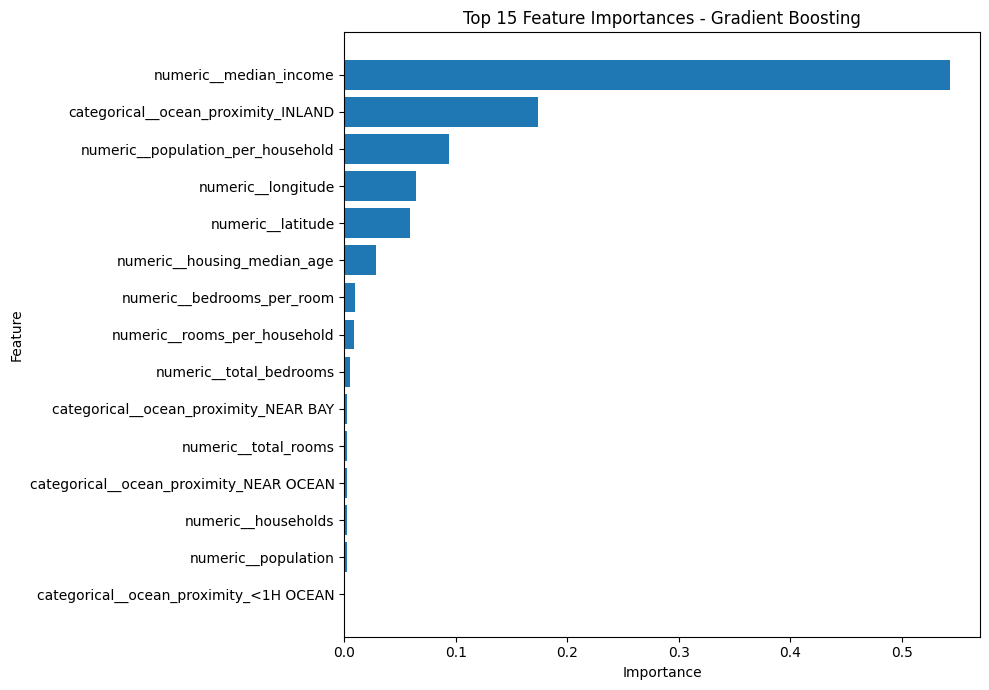

In [ ]:
# Top 15 Feature Importance Visualization

top_features = feature_importance_df.head(15).copy()

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

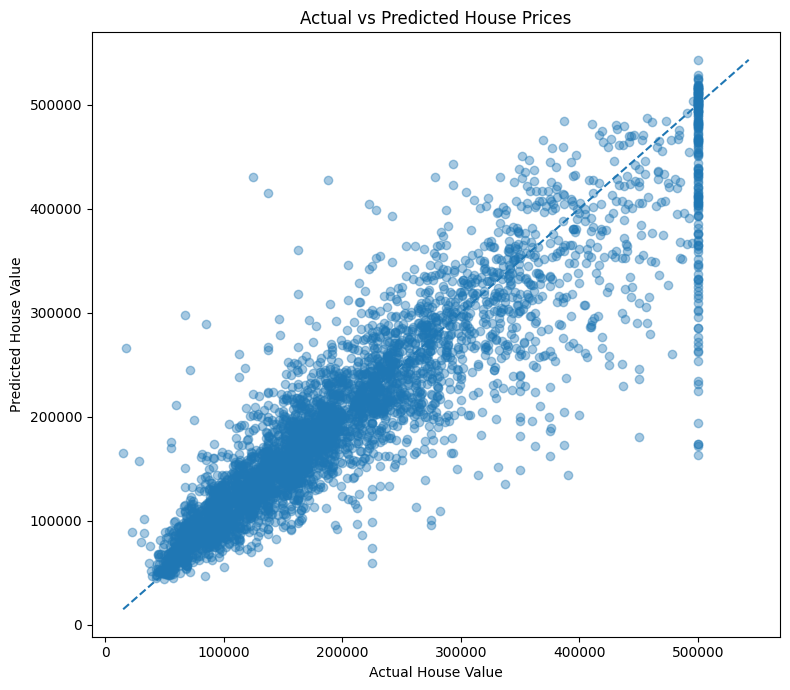

In [ ]:
# Actual vs Predicted House Prices

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.4
)

min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")

plt.tight_layout()
plt.show()

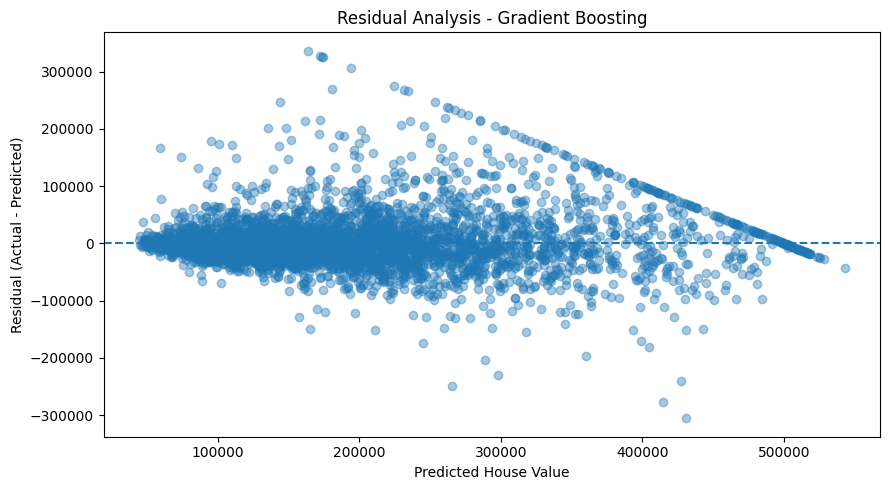

In [ ]:
# Residual Analysis

residuals = y_test - y_test_pred

plt.figure(figsize=(9, 5))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Residual Analysis - Gradient Boosting")
plt.xlabel("Predicted House Value")
plt.ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

In [ ]:
# FINAL MODEL PERFORMANCE

final_mae = mean_absolute_error(y_test, y_test_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
final_r2 = r2_score(y_test, y_test_pred)

print("FINAL MODEL - GRADIENT BOOSTING REGRESSOR")
print("=" * 55)
print(f"MAE              : ${final_mae:,.2f}")
print(f"RMSE             : ${final_rmse:,.2f}")
print(f"R² Score         : {final_r2:.4f}")
print(f"Variance Explained: {final_r2 * 100:.2f}%")
print("=" * 55)

print("\n5-FOLD CROSS-VALIDATION")
print("-" * 55)
print(f"Mean CV R²       : {cv_scores.mean():.4f}")
print(f"CV Std           : {cv_scores.std():.4f}")

FINAL MODEL - GRADIENT BOOSTING REGRESSOR
MAE              : $31,157.86
RMSE             : $48,322.68
R² Score         : 0.8218
Variance Explained: 82.18%

5-FOLD CROSS-VALIDATION
-------------------------------------------------------
Mean CV R²       : 0.8275
CV Std           : 0.0040


In [ ]:
# SAMPLE HOUSE PRICE PREDICTIONS

sample_results = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_test_pred[:10]
})

sample_results["Difference"] = (
    sample_results["Actual Price"]
    - sample_results["Predicted Price"]
)

sample_results["Actual Price"] = sample_results["Actual Price"].map(
    lambda x: f"${x:,.2f}"
)

sample_results["Predicted Price"] = sample_results["Predicted Price"].map(
    lambda x: f"${x:,.2f}"
)

sample_results["Difference"] = sample_results["Difference"].map(
    lambda x: f"${x:,.2f}"
)

display(sample_results)

,Actual Price,Predicted Price,Difference
0,"$47,700.00","$52,308.39","$-4,608.39"
1,"$45,800.00","$81,197.20","$-35,397.20"
2,"$500,001.00","$478,006.28","$21,994.72"
3,"$218,600.00","$241,360.05","$-22,760.05"
4,"$278,000.00","$242,876.85","$35,123.15"
5,"$158,700.00","$171,397.88","$-12,697.88"
6,"$198,200.00","$220,219.86","$-22,019.86"
7,"$157,500.00","$161,966.16","$-4,466.16"
8,"$340,000.00","$268,404.82","$71,595.18"
9,"$446,600.00","$470,832.52","$-24,232.52"


In [ ]:
import joblib

# Save the final trained model
joblib.dump(best_model, "california_housing_price_model.pkl")

print("Final model saved successfully!")
print("File: california_housing_price_model.pkl")

Final model saved successfully!
File: california_housing_price_model.pkl


In [ ]:
print("""
============================================================
       CALIFORNIA HOUSING PRICE PREDICTION
============================================================

Dataset:
California Housing Prices

Samples:
20,640

Target:
Median House Value

Final Model:
Gradient Boosting Regressor

Test R² Score:
0.8218

Variance Explained:
82.18%

MAE:
$31,157.86

RMSE:
$48,322.68

5-Fold Cross-Validation:
Mean R² = 0.8275
Std R²  = 0.0040

Important Features:
1. Median Income
2. Inland Location
3. Population per Household
4. Longitude
5. Latitude

Conclusion:
The Gradient Boosting model achieved strong and stable
performance in predicting California house values using
demographic, geographic, housing, and location-based
features.
============================================================
""")


       CALIFORNIA HOUSING PRICE PREDICTION

Dataset:
California Housing Prices

Samples:
20,640

Target:
Median House Value

Final Model:
Gradient Boosting Regressor

Test R² Score:
0.8218

Variance Explained:
82.18%

MAE:
$31,157.86

RMSE:
$48,322.68

5-Fold Cross-Validation:
Mean R² = 0.8275
Std R²  = 0.0040

Important Features:
1. Median Income
2. Inland Location
3. Population per Household
4. Longitude
5. Latitude

Conclusion:
The Gradient Boosting model achieved strong and stable
performance in predicting California house values using
demographic, geographic, housing, and location-based
features.

